## Import libraries

In [11]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Download the data

In [12]:
# parameters
ticker = 'SPY'
start_date = '2016-01-01'
end_date = '2026-01-01'

# download the data
print(f'Fetching data for {ticker}')
print(f'Time period {start_date} to {end_date}')

df = yf.download(ticker, start=start_date, end=end_date)
df.head()

[*********************100%***********************]  1 of 1 completed

Fetching data for SPY
Time period 2016-01-01 to 2026-01-01


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Date,,,,,
2016-01-04,169.471527,169.479953,167.422889,169.024707,222353500
2016-01-05,169.758240,170.213486,168.653835,169.791956,110845800
2016-01-06,167.616837,168.662220,166.588305,167.212159,152112600
2016-01-07,163.595459,166.453426,163.207647,164.674573,213436100
2016-01-08,161.799728,165.112954,161.513092,164.556532,209817200


## Calculate log return: (ln(price_today/price_yesterday))

We need this feature since log return will normalise the data and keep the math nice. Percentage increases are not symmetrical and log return is a good statistic for describing the volatility of the market.

In [13]:
# we only care about 'Close' price for this model
features = df[['Close']]
features.rename(columns={'Close':'Price'}, inplace=True)
features['log_return'] = np.log(features['Price'] / features['Price'].shift(1))

# drop the first row since it doesn't have a log return value
features = features.iloc[1:]

features.head()

Price,Price,log_return
Ticker,SPY,
Date,,
2016-01-05,169.758240,0.001690
2016-01-06,167.616837,-0.012695
2016-01-07,163.595459,-0.024284
2016-01-08,161.799728,-0.011037
2016-01-11,161.959946,0.000990


## Visualise the log returns

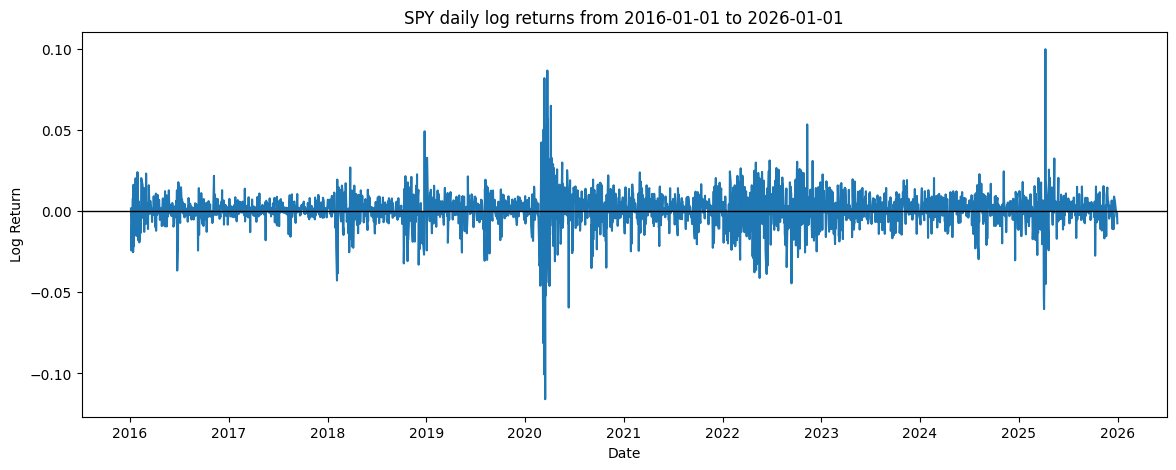

In [14]:
# plot the log returns to spot the high and low volatile regimes
plt.figure(figsize=(14, 5))
plt.plot(features.index, features['log_return'])
plt.title(f'{ticker} daily log returns from {start_date} to {end_date}')
plt.xlabel('Date')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linewidth=1) # add a horizontal line at y=0
plt.show()

## Calculate rolling average statistics

Calculate rolling average price for the last 20 days to see the trend of the market. Additionally, calculate the rolling average log return to be able to access the volatility of the market.

In [18]:
# calculate rolling average price for last 20 days
features['rolling_avg_price_20'] = features['Price'].rolling(20).mean()

# calculate rolling average log return for last 20 days
features['rolling_avg_return_20'] = features['log_return'].rolling(20).mean()

# drop the nan columns
features.dropna(inplace=True)

features.head(10)

Price,Price,log_return,rolling_avg_price_20,rolling_avg_return_20
Ticker,SPY,,,
Date,,,,
2016-02-02,160.315964,-0.018186,161.193580,-0.002777
2016-02-03,161.277023,0.005977,160.769519,-0.002563
2016-02-04,161.529907,0.001567,160.465173,-0.001850
2016-02-05,158.452774,-0.019234,160.208038,-0.001597
2016-02-08,156.319901,-0.013552,159.934047,-0.001723
2016-02-09,156.328293,0.000054,159.652464,-0.001770
2016-02-10,156.193405,-0.000863,159.298802,-0.002214
2016-02-11,154.161621,-0.013093,159.047147,-0.001606


## Visualise features

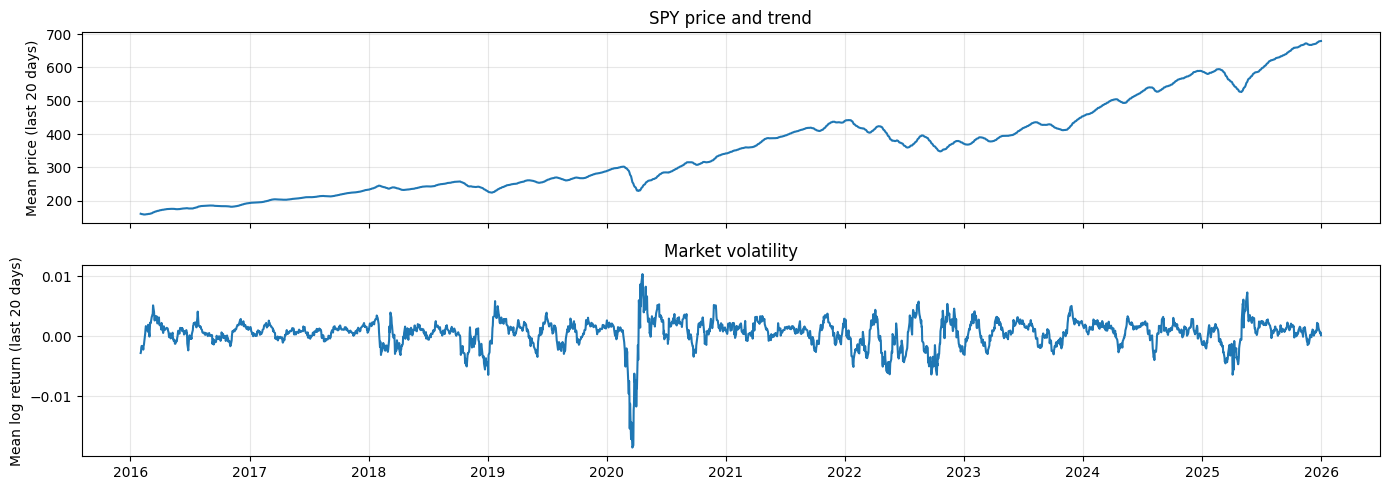

In [29]:
# create a stacked plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax1.plot(features.index, features['rolling_avg_price_20'])
ax2.plot(features.index, features['rolling_avg_return_20'])
ax1.set_title(f'{ticker} price and trend')
ax1.set_ylabel('Mean price (last 20 days)')
ax2.set_title('Market volatility')
ax2.set_ylabel('Mean log return (last 20 days)')
ax1.grid(alpha=0.3)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()